# AI-Based Predictive Maintenance & Fault Intelligence System for Telecom Infrastructure

This notebook builds an end-to-end machine learning workflow for predicting failures in telecom infrastructure equipment. The public AI4I 2020 predictive maintenance dataset is used as a realistic proxy for telemetry collected from 5G base station cooling systems, RAN cabinet hardware, telecom edge servers, optical transport modules, power systems, and signal processing units.

The objective is to predict equipment failure, identify likely failure types, detect anomalous operating conditions, and explain the strongest root-cause indicators behind infrastructure risk.

## 1. Environment Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from src.config import FIGURES_DIR, MODELS_DIR, PROCESSED_DATA_DIR, RANDOM_STATE
from src.data_preprocessing import load_and_prepare_data, save_processed_data
from src.features import add_engineered_features
from src.modeling import (
    model_diagnostics,
    save_artifacts,
    train_failure_type_classifier,
    train_isolation_forest,
    train_supervised_models,
)
from src.visualization import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_correlation_heatmap,
    plot_metric_comparison,
    plot_precision_recall_curve,
    plot_roc_curve,
    set_plot_style,
)

set_plot_style()
pd.set_option("display.max_columns", 40)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Telecom-Framed Dataset

The dataset is converted from generic industrial terminology into telecom infrastructure terminology. This keeps the analysis focused on network equipment reliability rather than a generic classroom classification task.

In [2]:
df = load_and_prepare_data()
df = add_engineered_features(df)
save_processed_data(df)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 10,000
Columns: 21


,Type,ambient_cabinet_temp_k,processing_unit_temp_k,cooling_fan_speed_rpm,mechanical_load_nm,component_wear_min,equipment_failure,component_wear_failure,thermal_dissipation_failure,power_delivery_failure,overload_stress_failure,random_node_failure,failure_type,temp_delta_k,cabinet_temp_c,processing_temp_c,estimated_power_load,wear_load_interaction,thermal_stress_index,cooling_efficiency_index,speed_torque_ratio
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,none,10.5,24.95,35.45,6.951079,0.0,449.40,5.025924,36.238317
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,none,10.5,25.05,35.55,6.826220,138.9,486.15,4.561063,30.410367
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,none,10.4,24.95,35.35,7.748817,247.0,513.76,4.855754,30.323886
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,none,10.4,25.05,35.45,5.927068,276.5,410.80,4.643552,36.278480
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,none,10.5,25.05,35.55,5.897382,360.0,420.00,4.561063,35.199999


## 3. Dataset Inspection

In [3]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Type                         10000 non-null  object 
 1   ambient_cabinet_temp_k       10000 non-null  float64
 2   processing_unit_temp_k       10000 non-null  float64
 3   cooling_fan_speed_rpm        10000 non-null  int64  
 4   mechanical_load_nm           10000 non-null  float64
 5   component_wear_min           10000 non-null  int64  
 6   equipment_failure            10000 non-null  int64  
 7   component_wear_failure       10000 non-null  int64  
 8   thermal_dissipation_failure  10000 non-null  int64  
 9   power_delivery_failure       10000 non-null  int64  
 10  overload_stress_failure      10000 non-null  int64  
 11  random_node_failure          10000 non-null  int64  
 12  failure_type                 10000 non-null  object 
 13  temp_delta_k     

,count,mean,std,min,25%,50%,75%,max
ambient_cabinet_temp_k,10000.0,300.004930,2.000259,295.300000,298.300000,300.100000,301.500000,304.500000
processing_unit_temp_k,10000.0,310.005560,1.483734,305.700000,308.800000,310.100000,311.100000,313.800000
cooling_fan_speed_rpm,10000.0,1538.776100,179.284096,1168.000000,1423.000000,1503.000000,1612.000000,2886.000000
mechanical_load_nm,10000.0,39.986910,9.968934,3.800000,33.200000,40.100000,46.800000,76.600000
component_wear_min,10000.0,107.951000,63.654147,0.000000,53.000000,108.000000,162.000000,253.000000
equipment_failure,10000.0,0.033900,0.180981,0.000000,0.000000,0.000000,0.000000,1.000000
component_wear_failure,10000.0,0.004600,0.067671,0.000000,0.000000,0.000000,0.000000,1.000000
thermal_dissipation_failure,10000.0,0.011500,0.106625,0.000000,0.000000,0.000000,0.000000,1.000000
power_delivery_failure,10000.0,0.009500,0.097009,0.000000,0.000000,0.000000,0.000000,1.000000
overload_stress_failure,10000.0,0.009800,0.098514,0.000000,0.000000,0.000000,0.000000,1.000000


In [4]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0] if missing_values.sum() else "No missing values detected"

'No missing values detected'

## 4. Failure Imbalance Analysis

Telecom infrastructure failures are rare compared with normal operating telemetry. This imbalance matters because a model can look accurate by predicting most equipment as healthy while missing the failure cases that operations teams care about most. Recall, F1-score, ROC-AUC, and precision-recall performance are more important than accuracy alone.

Observed failure rate: 3.39%


failure_type
none                           9652
thermal_dissipation_failure     115
power_delivery_failure           91
overload_stress_failure          78
component_wear_failure           46
random_node_failure              18
Name: count, dtype: int64

<Axes: title={'center': 'Telecom Infrastructure Failure Distribution'}, xlabel='Equipment Failure', ylabel='Number of Records'>

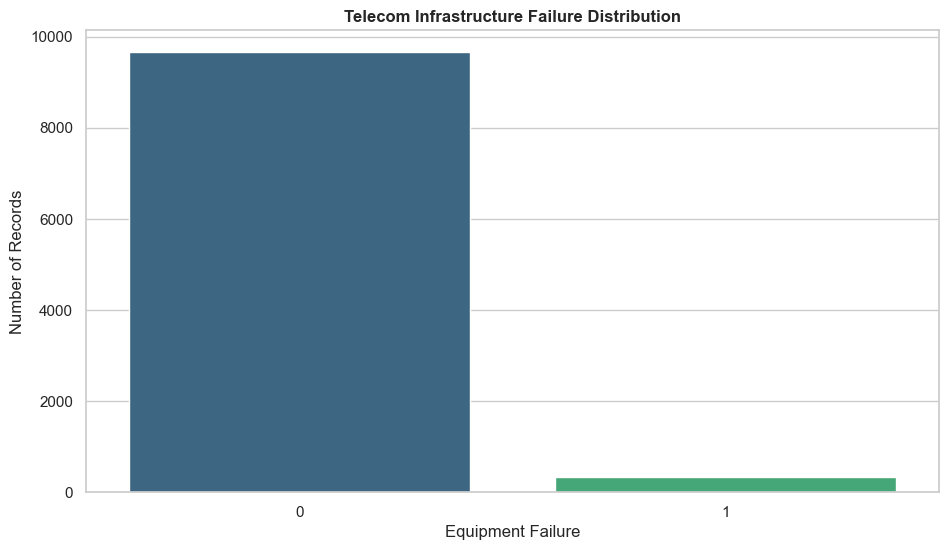

In [5]:
failure_rate = df["equipment_failure"].mean() * 100
print(f"Observed failure rate: {failure_rate:.2f}%")
display(df["failure_type"].value_counts())
plot_class_distribution(df)

## 5. Sensor and Reliability Feature Analysis

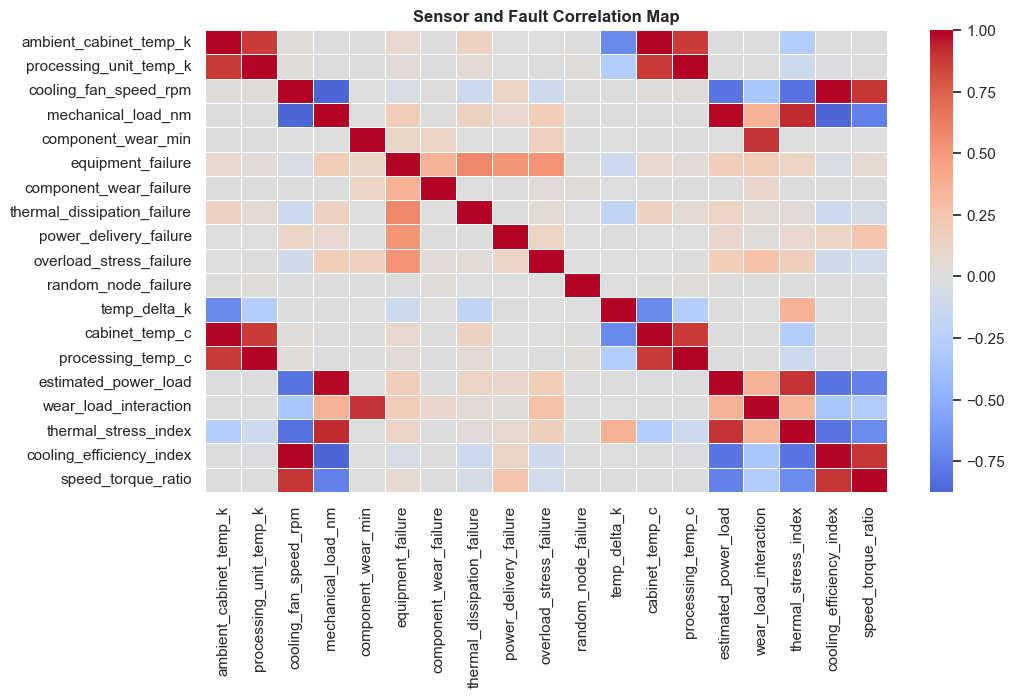

In [6]:
plot_correlation_heatmap(df)
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=160, bbox_inches="tight")

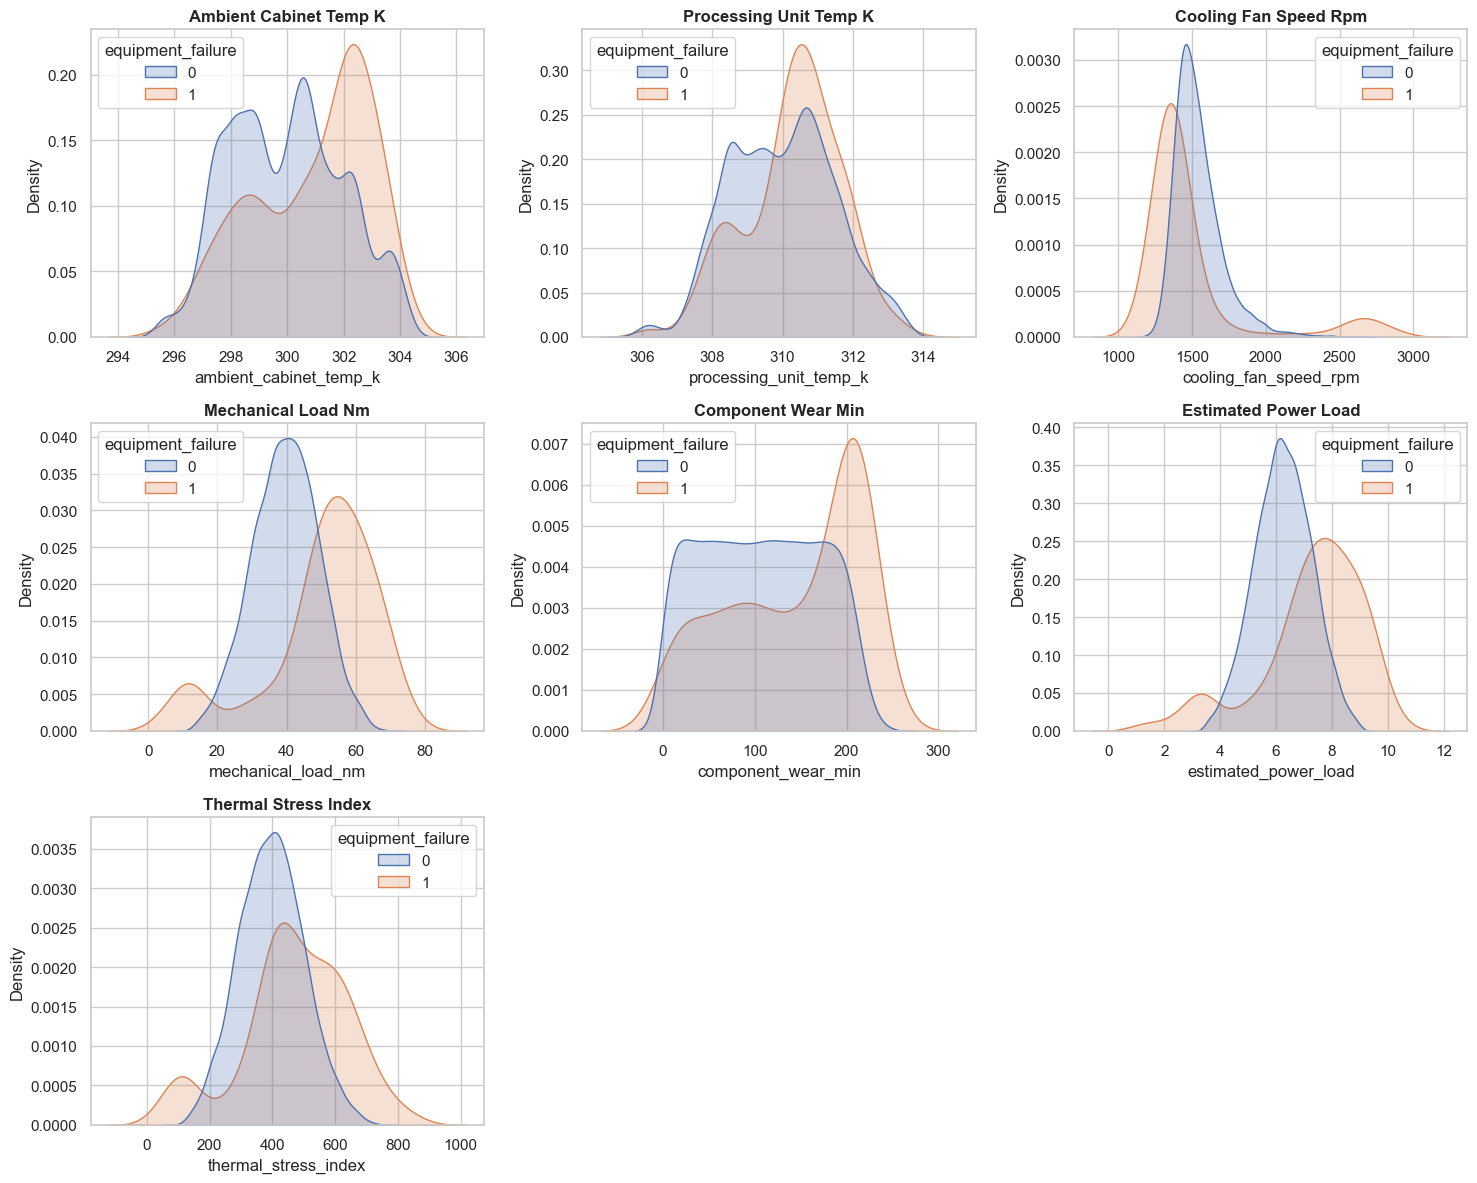

In [7]:
sensor_cols = [
    "ambient_cabinet_temp_k",
    "processing_unit_temp_k",
    "cooling_fan_speed_rpm",
    "mechanical_load_nm",
    "component_wear_min",
    "estimated_power_load",
    "thermal_stress_index",
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for ax, col in zip(axes, sensor_cols):
    sns.kdeplot(data=df, x=col, hue="equipment_failure", common_norm=False, fill=True, ax=ax)
    ax.set_title(col.replace("_", " ").title())
for ax in axes[len(sensor_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sensor_distribution_by_failure.png", dpi=160, bbox_inches="tight")

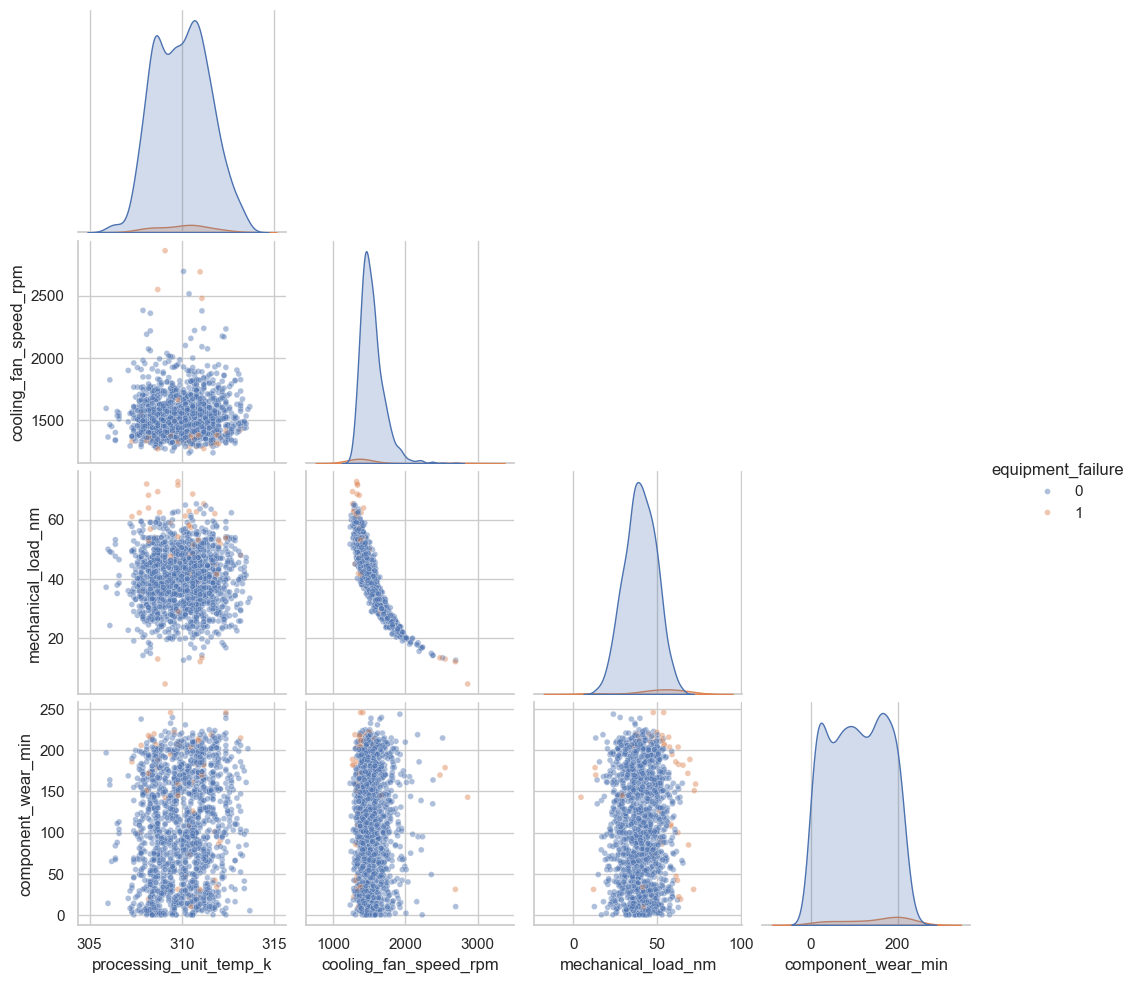

In [8]:
pairplot_sample = df.sample(n=min(1500, len(df)), random_state=RANDOM_STATE)
sns.pairplot(
    pairplot_sample,
    vars=["processing_unit_temp_k", "cooling_fan_speed_rpm", "mechanical_load_nm", "component_wear_min"],
    hue="equipment_failure",
    corner=True,
    plot_kws={"alpha": 0.45, "s": 18},
)
plt.savefig(FIGURES_DIR / "telecom_sensor_pairplot.png", dpi=160, bbox_inches="tight")

## 6. Feature Engineering

The engineered features convert raw equipment telemetry into operational reliability indicators. For telecom field infrastructure, thermal delta, load stress, cooling efficiency, and wear-load interaction are more actionable than raw sensor values alone.

In [9]:
engineered_cols = [
    "temp_delta_k",
    "cabinet_temp_c",
    "processing_temp_c",
    "estimated_power_load",
    "wear_load_interaction",
    "thermal_stress_index",
    "cooling_efficiency_index",
    "speed_torque_ratio",
]
df[engineered_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temp_delta_k,10000.0,10.000630,1.001094,7.600000,9.300000,9.800000,11.000000,12.100000
cabinet_temp_c,10000.0,26.854930,2.000259,22.150000,25.150000,26.950000,28.350000,31.350000
processing_temp_c,10000.0,36.855560,1.483734,32.550000,35.650000,36.950000,37.950000,40.650000
estimated_power_load,10000.0,6.279282,1.067340,1.148356,5.560775,6.270565,7.002487,10.469152
wear_load_interaction,10000.0,4314.664550,2826.567692,0.000000,1963.650000,4012.950000,6279.000000,16497.000000
thermal_stress_index,10000.0,399.961047,107.725221,36.860000,325.360000,398.820000,470.455000,857.920000
cooling_efficiency_index,10000.0,4.963765,0.578302,3.802083,4.590137,4.847704,5.200902,9.370130
speed_torque_ratio,10000.0,43.167215,25.053905,15.665796,30.482987,37.403703,48.449456,759.473484


## 7. Supervised Failure Prediction

The supervised models predict whether a telecom infrastructure node is likely to fail. SMOTE is applied only to the training split so minority failure patterns are better represented during learning while the test split remains realistic.

In [10]:
artifacts = train_supervised_models(df)
metrics = artifacts.metrics
display(metrics.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1_score": "{:.3f}",
    "roc_auc": "{:.3f}",
    "avg_precision": "{:.3f}",
}))
print(f"Best recall-oriented model: {artifacts.best_model_name}")

,model,accuracy,precision,recall,f1_score,roc_auc,avg_precision
0,Logistic Regression,0.859,0.181,0.897,0.301,0.940,0.449
2,Gradient Boosting,0.960,0.450,0.868,0.593,0.978,0.865
1,Random Forest,0.978,0.633,0.838,0.722,0.980,0.836
3,XGBoost,0.972,0.559,0.838,0.671,0.981,0.871


Best recall-oriented model: Logistic Regression


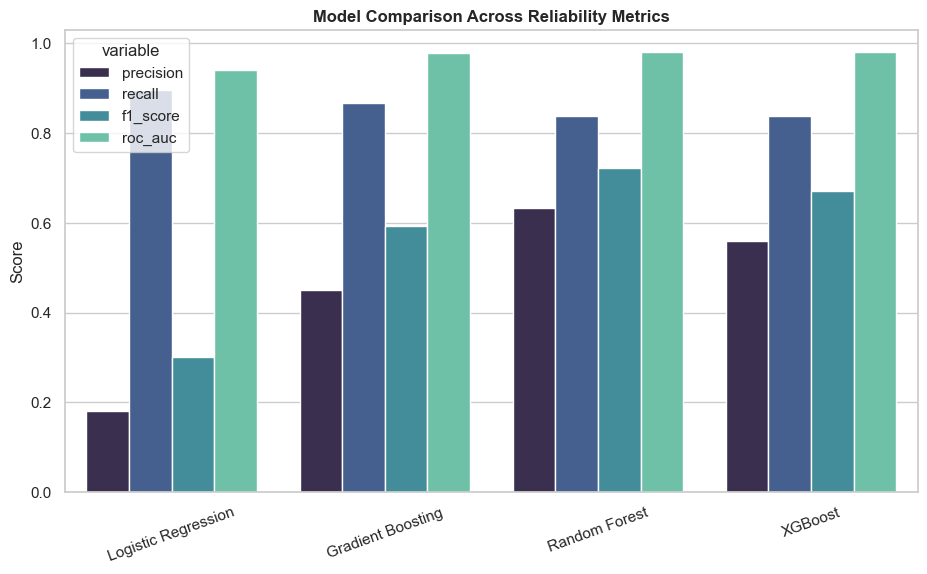

In [11]:
plot_metric_comparison(metrics)
plt.savefig(FIGURES_DIR / "model_comparison_metrics.png", dpi=160, bbox_inches="tight")

## 8. Model Diagnostics

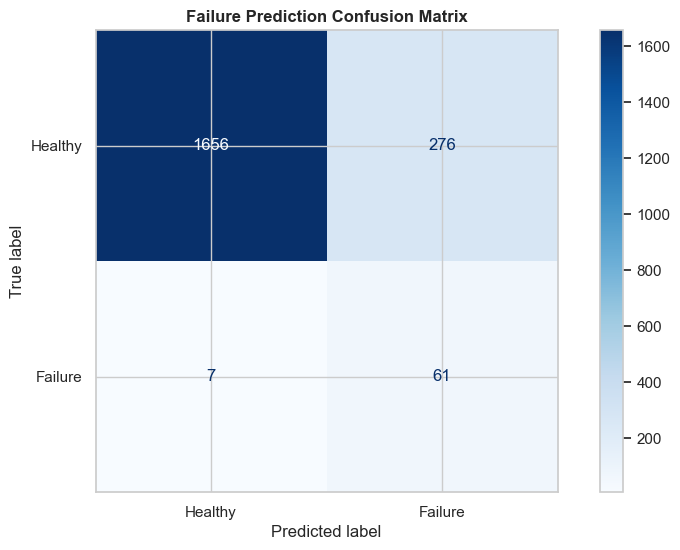

In [12]:
best_model = artifacts.models[artifacts.best_model_name]
diagnostics = model_diagnostics(best_model, artifacts.X_test, artifacts.y_test)

plot_confusion_matrix(diagnostics["confusion_matrix"], ["Healthy", "Failure"])
plt.savefig(FIGURES_DIR / "confusion_matrix_best_model.png", dpi=160, bbox_inches="tight")

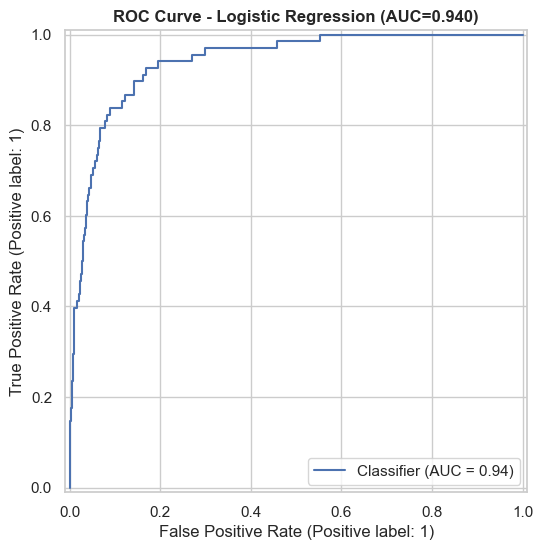

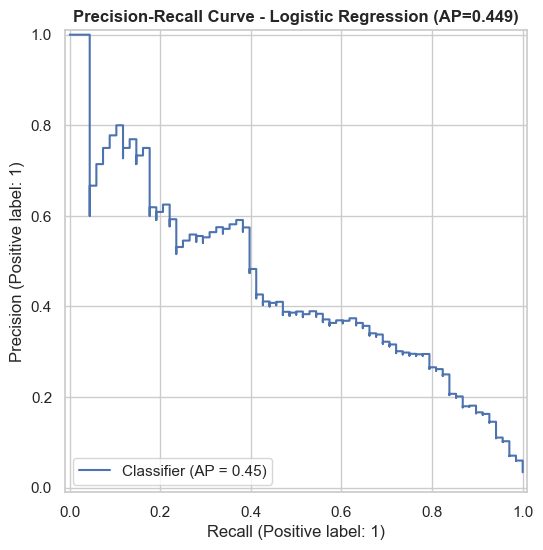

In [13]:
plot_roc_curve(artifacts.y_test, diagnostics["probabilities"], artifacts.best_model_name)
plt.savefig(FIGURES_DIR / "roc_curve_best_model.png", dpi=160, bbox_inches="tight")

plot_precision_recall_curve(artifacts.y_test, diagnostics["probabilities"], artifacts.best_model_name)
plt.savefig(FIGURES_DIR / "precision_recall_curve_best_model.png", dpi=160, bbox_inches="tight")

## 9. Failure Type Classification

After detecting high-risk equipment, operations teams also need likely root-cause categories. A separate classifier is trained only on failed records to classify failure type.

In [14]:
failure_type_model = train_failure_type_classifier(df)
fault_cases = df[df["failure_type"] != "none"].copy()
fault_predictions = failure_type_model.predict(fault_cases[artifacts.X_train.columns])
pd.crosstab(fault_cases["failure_type"], fault_predictions, rownames=["Actual"], colnames=["Predicted"])

Predicted,component_wear_failure,overload_stress_failure,power_delivery_failure,random_node_failure,thermal_dissipation_failure
Actual,,,,,
component_wear_failure,46,0,0,0,0
overload_stress_failure,0,78,0,0,0
power_delivery_failure,0,0,91,0,0
random_node_failure,0,0,0,18,0
thermal_dissipation_failure,0,0,0,0,115


## 10. Unsupervised Anomaly Detection

Isolation Forest is used to identify abnormal infrastructure behavior without relying on failure labels. This is useful when newly deployed telecom assets do not yet have enough labeled failures but abnormal telemetry patterns still need to be surfaced.

In [15]:
anomaly_model = train_isolation_forest(df)
anomaly_labels = anomaly_model.predict(df[artifacts.X_train.columns])
anomaly_scores = anomaly_model.named_steps["model"].decision_function(
    anomaly_model.named_steps["preprocess"].transform(df[artifacts.X_train.columns])
)

df_anomaly = df.copy()
df_anomaly["anomaly_flag"] = np.where(anomaly_labels == -1, 1, 0)
df_anomaly["anomaly_score"] = anomaly_scores

pd.crosstab(df_anomaly["equipment_failure"], df_anomaly["anomaly_flag"], rownames=["Failure"], colnames=["Anomaly"])


Anomaly,0,1
Failure,,
0,9387,274
1,274,65


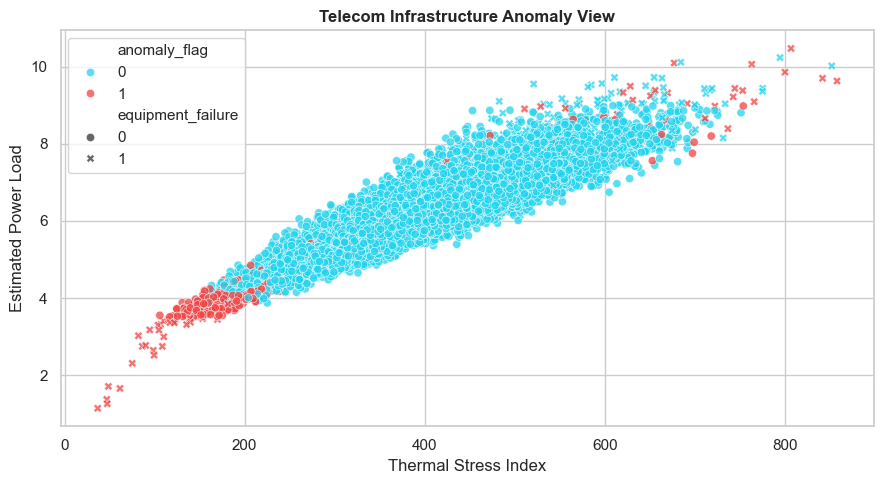

In [16]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_anomaly,
    x="thermal_stress_index",
    y="estimated_power_load",
    hue="anomaly_flag",
    style="equipment_failure",
    palette={0: "#22d3ee", 1: "#ef4444"},
    alpha=0.75,
)
plt.title("Telecom Infrastructure Anomaly View")
plt.xlabel("Thermal Stress Index")
plt.ylabel("Estimated Power Load")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "anomaly_scatter.png", dpi=160, bbox_inches="tight")

## 11. SHAP Root-Cause Explainability

SHAP explains which telemetry conditions pushed model decisions toward failure risk. For telecom operations, this helps translate a model score into practical maintenance reasoning.

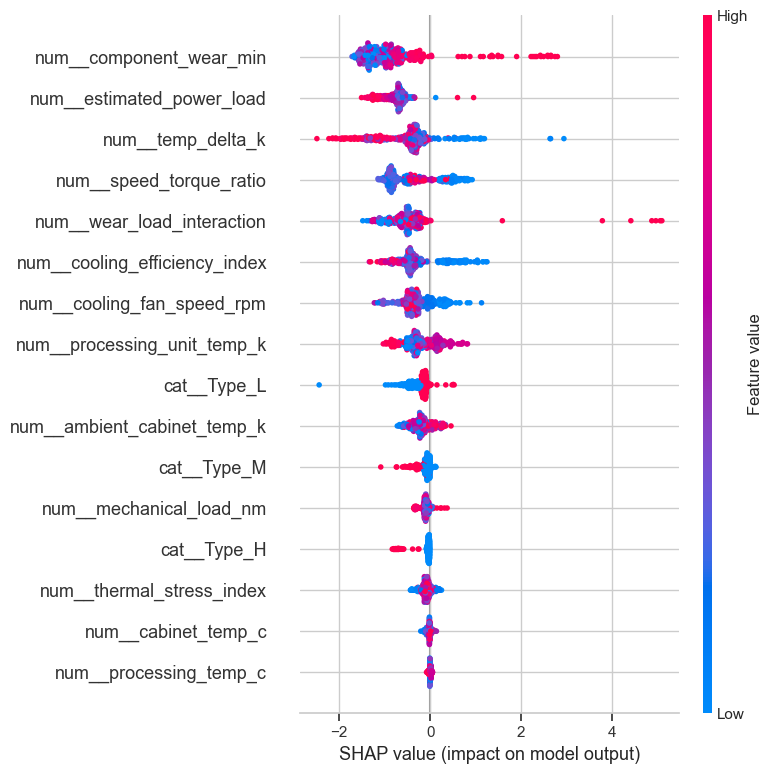

In [17]:
tree_model_name = "XGBoost" if "XGBoost" in artifacts.models else artifacts.best_model_name
tree_pipeline = artifacts.models[tree_model_name]
preprocessor = tree_pipeline.named_steps["preprocess"]
model = tree_pipeline.named_steps["model"]

X_shap = artifacts.X_test.sample(n=min(400, len(artifacts.X_test)), random_state=RANDOM_STATE)
X_shap_transformed = preprocessor.transform(X_shap)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.Explainer(model)
shap_values = explainer(X_shap_transformed)

shap.summary_plot(shap_values, X_shap_transformed, feature_names=feature_names, show=False)
plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=160, bbox_inches="tight")
plt.show()

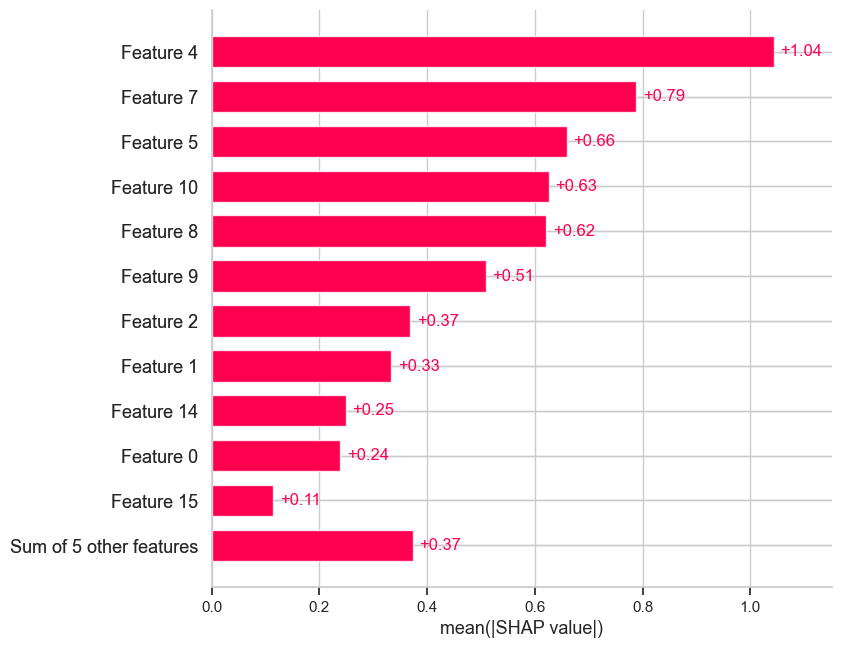

In [18]:
shap.plots.bar(shap_values, max_display=12, show=False)
plt.savefig(FIGURES_DIR / "shap_bar.png", dpi=160, bbox_inches="tight")
plt.show()

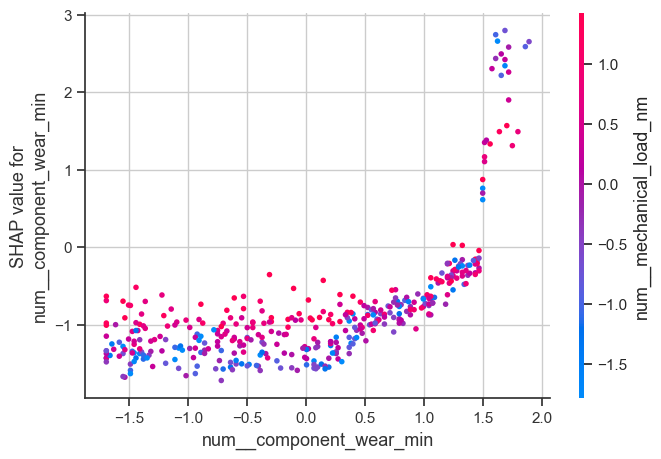

In [19]:
top_feature_idx = np.abs(shap_values.values).mean(axis=0).argmax()
shap.dependence_plot(
    top_feature_idx,
    shap_values.values,
    X_shap_transformed,
    feature_names=feature_names,
    show=False,
)
plt.savefig(FIGURES_DIR / "shap_dependence.png", dpi=160, bbox_inches="tight")
plt.show()

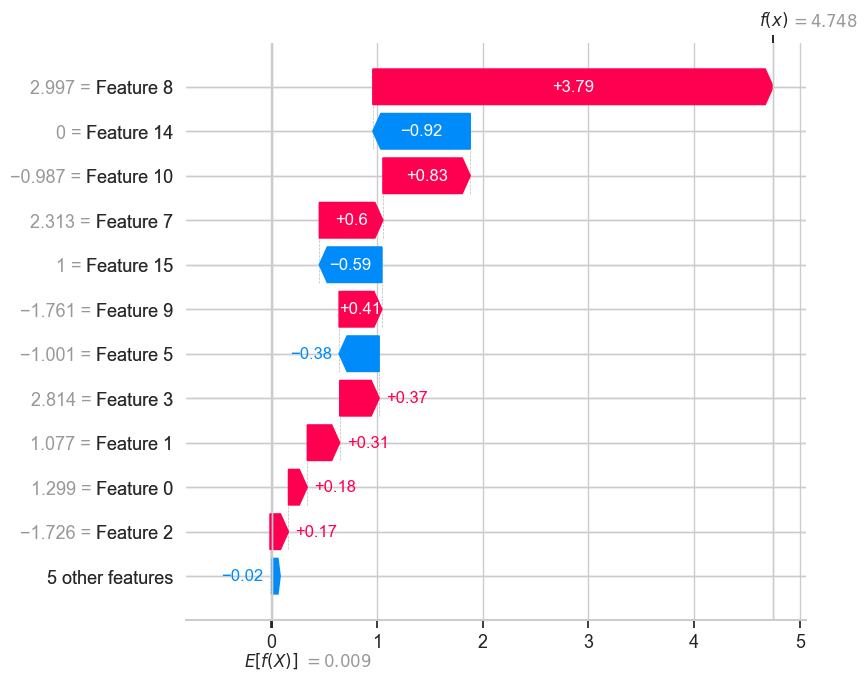

In [20]:
risk_scores = best_model.predict_proba(X_shap)[:, 1]
highest_risk_position = int(np.argmax(risk_scores))
shap.plots.waterfall(shap_values[highest_risk_position], max_display=12, show=False)
plt.savefig(FIGURES_DIR / "shap_waterfall_high_risk.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Save Models and Sample Prediction

In [21]:
save_artifacts(best_model, failure_type_model, anomaly_model, metrics)
print("Saved model artifacts to", MODELS_DIR)

Saved model artifacts to D:\project\telecom_fault_intelligence_ml\models


In [22]:
sample_node = pd.DataFrame([
    {
        "ambient_cabinet_temp_k": 298.1,
        "processing_unit_temp_k": 309.2,
        "cooling_fan_speed_rpm": 1385,
        "mechanical_load_nm": 51.6,
        "component_wear_min": 184,
        "Type": "H",
    }
])
sample_node = add_engineered_features(sample_node)
failure_probability = best_model.predict_proba(sample_node[artifacts.X_train.columns])[:, 1][0]
failure_type = failure_type_model.predict(sample_node[artifacts.X_train.columns])[0]

print(f"Predicted infrastructure failure probability: {failure_probability:.2%}")
print(f"Likely failure mode if degraded: {failure_type}")

Predicted infrastructure failure probability: 31.58%
Likely failure mode if degraded: overload_stress_failure


## 13. Telecom Business Insights

- Predictive maintenance protects network availability by identifying site equipment degradation before outage events.
- Failure recall is operationally important because missed failures can lead to SLA impact, truck rolls, and customer-facing service degradation.
- Thermal stress, load conditions, and wear indicators provide actionable maintenance signals for distributed telecom infrastructure.
- Supervised models are useful when historical fault labels exist; unsupervised anomaly detection is useful for newer equipment where labeled failures are limited.
- SHAP explainability helps translate model output into maintenance reasoning that operations teams can trust.